In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import re
import string
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving True.csv to True.csv


In [4]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (44898, 5)
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  


In [5]:
df = df[["title", "text", "label"]].copy()

df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

print(df.shape)
print(df["label"].value_counts())

(44898, 2)
label
0    23481
1    21417
Name: count, dtype: int64


In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate records:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("\nDataset after removing duplicates:", df.shape)

Missing values:
content    0
label      0
dtype: int64

Duplicate records: 5793

Dataset after removing duplicates: (39105, 2)


label
1    21197
0    17908
Name: count, dtype: int64


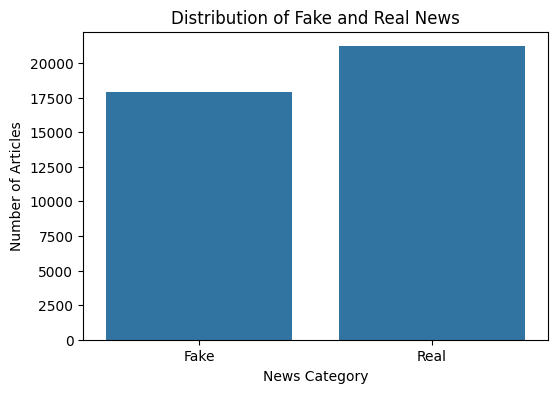

In [7]:
print(df["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df)
plt.xticks([0, 1], ["Fake", "Real"])
plt.xlabel("News Category")
plt.ylabel("Number of Articles")
plt.title("Distribution of Fake and Real News")
plt.show()

count    39105.000000
mean      2505.880629
std       1943.950515
min         31.000000
25%       1348.000000
50%       2288.000000
75%       3163.000000
max      51893.000000
Name: text_length, dtype: float64


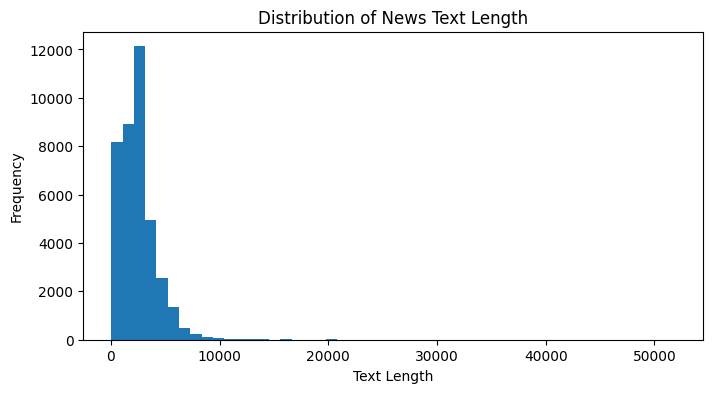

In [8]:
df["text_length"] = df["content"].str.len()

print(df["text_length"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["text_length"], bins=50)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of News Text Length")
plt.show()

In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [10]:
df["clean_text"] = df["content"].apply(clean_text)

df[["content", "clean_text", "label"]].head()

,content,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year’s eve...,0
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama’s name coded website...,0
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...,0


In [11]:
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Final dataset size:", df.shape)

Final dataset size: (39100, 4)


In [12]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31280
Testing samples: 7820


In [13]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature matrix:", X_train_tfidf.shape)
print("Testing feature matrix:", X_test_tfidf.shape)

Training feature matrix: (31280, 50000)
Testing feature matrix: (7820, 50000)


In [14]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

logistic_pred = logistic_model.predict(X_test_tfidf)

In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

In [16]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [17]:
models = {
    "Logistic Regression": logistic_pred,
    "Naive Bayes": nb_pred,
    "Linear SVM": svm_pred
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.989003,0.983920,0.995990,0.989918
1,Naive Bayes,0.958056,0.959361,0.963435,0.961394
2,Linear SVM,0.994373,0.991794,0.997877,0.994826


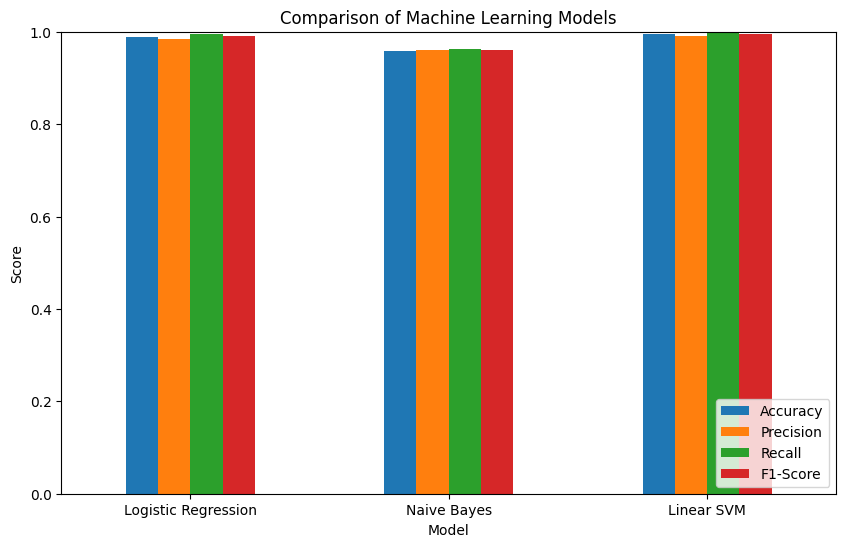

In [18]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Comparison of Machine Learning Models")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [19]:
print("Logistic Regression")
print(classification_report(
    y_test,
    logistic_pred,
    target_names=["Fake", "Real"]
))

Logistic Regression
              precision    recall  f1-score   support

        Fake       1.00      0.98      0.99      3581
        Real       0.98      1.00      0.99      4239

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820



In [20]:
print("Naive Bayes")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Fake", "Real"]
))

Naive Bayes
              precision    recall  f1-score   support

        Fake       0.96      0.95      0.95      3581
        Real       0.96      0.96      0.96      4239

    accuracy                           0.96      7820
   macro avg       0.96      0.96      0.96      7820
weighted avg       0.96      0.96      0.96      7820



In [21]:
print("Linear SVM")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Fake", "Real"]
))

Linear SVM
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3581
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820



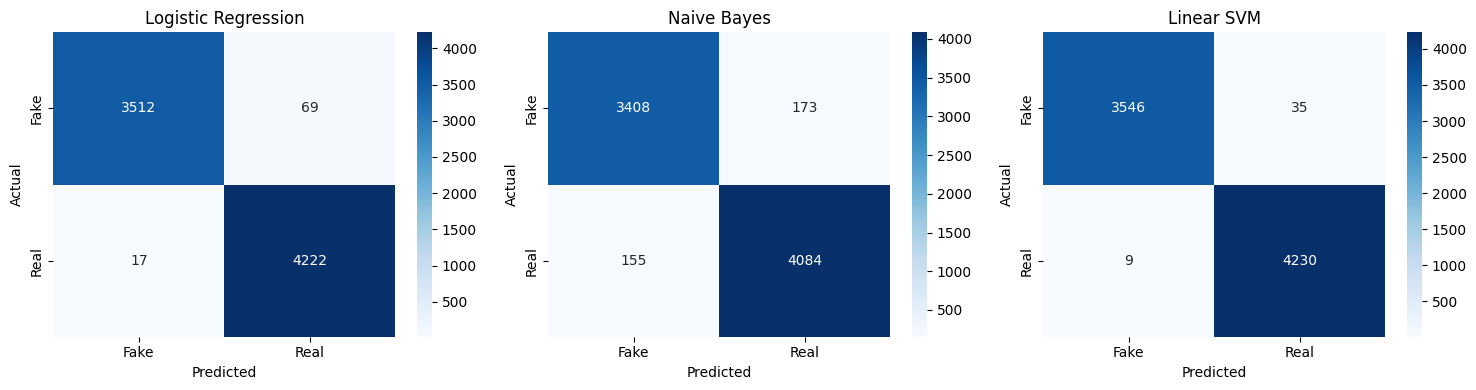

In [22]:
predictions = {
    "Logistic Regression": logistic_pred,
    "Naive Bayes": nb_pred,
    "Linear SVM": svm_pred
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, prediction) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, prediction)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"],
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [23]:
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(), "Model"
]

print("Best-performing model:", best_model_name)

print(
    results_df[
        results_df["Model"] == best_model_name
    ]
)

Best-performing model: Linear SVM
        Model  Accuracy  Precision    Recall  F1-Score
2  Linear SVM  0.994373   0.991794  0.997877  0.994826


In [24]:
trained_models = {
    "Logistic Regression": logistic_model,
    "Naive Bayes": nb_model,
    "Linear SVM": svm_model
}

best_model = trained_models[best_model_name]

In [25]:
def predict_news(news_text):
    cleaned = clean_text(news_text)
    features = tfidf.transform([cleaned])
    prediction = best_model.predict(features)[0]

    if prediction == 0:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"

In [28]:
news = input("Enter news text: ")

result = predict_news(news)

print("Prediction:", result)

Enter news text: WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a â€œfiscal conservativeâ€ on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBSâ€™ â€œFace the Nation,â€ drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-defense â€œdiscretionaryâ€ spending o